<a href="https://colab.research.google.com/github/mfachriridwan/claude/blob/main/MSW_pathway_model_v3/MSW_Decision_Tool_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSW Recovery-Pathway Decision Tool (v3.2)
**Under what Indonesian city and waste-system conditions does each recovery pathway become preferable?**
*Pada kondisi kota dan sistem persampahan seperti apa setiap jalur pengolahan menjadi pilihan terbaik?*

This notebook screens six options per tonne of mixed municipal solid waste at the facility gate in 2025:
sanitary landfill with flare (SL), waste-to-energy (S1), RDF to cement kiln (S2), anaerobic digestion of food waste (S3),
PHB from landfill gas (S4) and integrated RDF + AD (S5). Indicators: climate change (GWP100), net cost, fossil
cumulative energy demand and land take. Every number comes from the CSV files in `data/`, each with its source and status.

**Ex-ante decision support.** None of these facilities exists yet in the 21 locations. The tool tells local
governments, planners and funders, before a feasibility study or tender, which options are worth pursuing under their
conditions, which performance targets an option would have to meet to beat a sanitary landfill, and which local data
are worth collecting first. The ranking criterion is the **carbon-inclusive cost** C + pG/1000 (USD per tonne) at a
carbon value p that the user chooses; it is not a full social cost.

| Step | What you get |
|---|---|
| 0 | Setup (about 1 minute in Colab) |
| 1 | Results for the 21 RIPS cities/regencies |
| 2 | Results for **your own cities** from an uploaded template |
| 3 | An interactive form for one city |
| 4 | **Decision rules**: the conditions under which each option wins (scenario discovery) |
| 5 | **Break-even targets** and **what to measure first** (value of information) |

*Screening-level study: read the caveats in Step 5 before using results for decisions.*

## Step 0. Setup / Persiapan

In [1]:
import os, sys, subprocess, pathlib
REPO_URL = "https://github.com/mfachriridwan/claude.git"
BRANCH = "main"          # branch that contains the MSW_pathway_model_v3 folder
IN_COLAB = "google.colab" in sys.modules

def _here(p): return pathlib.Path(p, "mswpath").exists()
if not _here("."):
    if _here("MSW_pathway_model_v3"):
        os.chdir("MSW_pathway_model_v3")
    elif IN_COLAB:
        r = subprocess.run(["git", "clone", "--depth", "1", "-b", BRANCH, REPO_URL, "repo"])
        if r.returncode == 0 and _here("repo/MSW_pathway_model_v3"):
            os.chdir("repo/MSW_pathway_model_v3")
        else:   # private repository or no network: upload the release ZIP instead
            from google.colab import files
            print("Clone failed. Upload MSW_v3_results.zip / Gagal clone, unggah file ZIP:")
            up = files.upload(); z = next(iter(up))
            subprocess.run(["unzip", "-q", "-o", z]); os.chdir("MSW_pathway_model_v3")
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
    from google.colab import output; output.enable_custom_widget_manager()
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from mswpath import MSWModel, read_input, PW, NAMES, __version__
from mswpath.inputs import from_template, validate_template
from mswpath.report import analyse, central_table, prob_figure, write_excel, write_html
print("mswpath", __version__, "| working directory:", os.getcwd())

mswpath 3.2.0 | working directory: /home/user/claude/MSW_pathway_model_v3


Choose the language of tables and reports / Pilih bahasa tabel dan laporan (`'en'` or `'id'`).

In [2]:
LANG = "id"
M = MSWModel("data")
pathlib.Path("outputs/user_reports").mkdir(parents=True, exist_ok=True)

## Step 1. The 21 RIPS cities/regencies / 21 kota-kabupaten RIPS
Uses `data/input_kota_2025_updated.csv` (2025 baseline, provenance and quality flags in each row).
1,000 Monte Carlo draws per location keeps this step to about a minute; the paper uses 4,000.

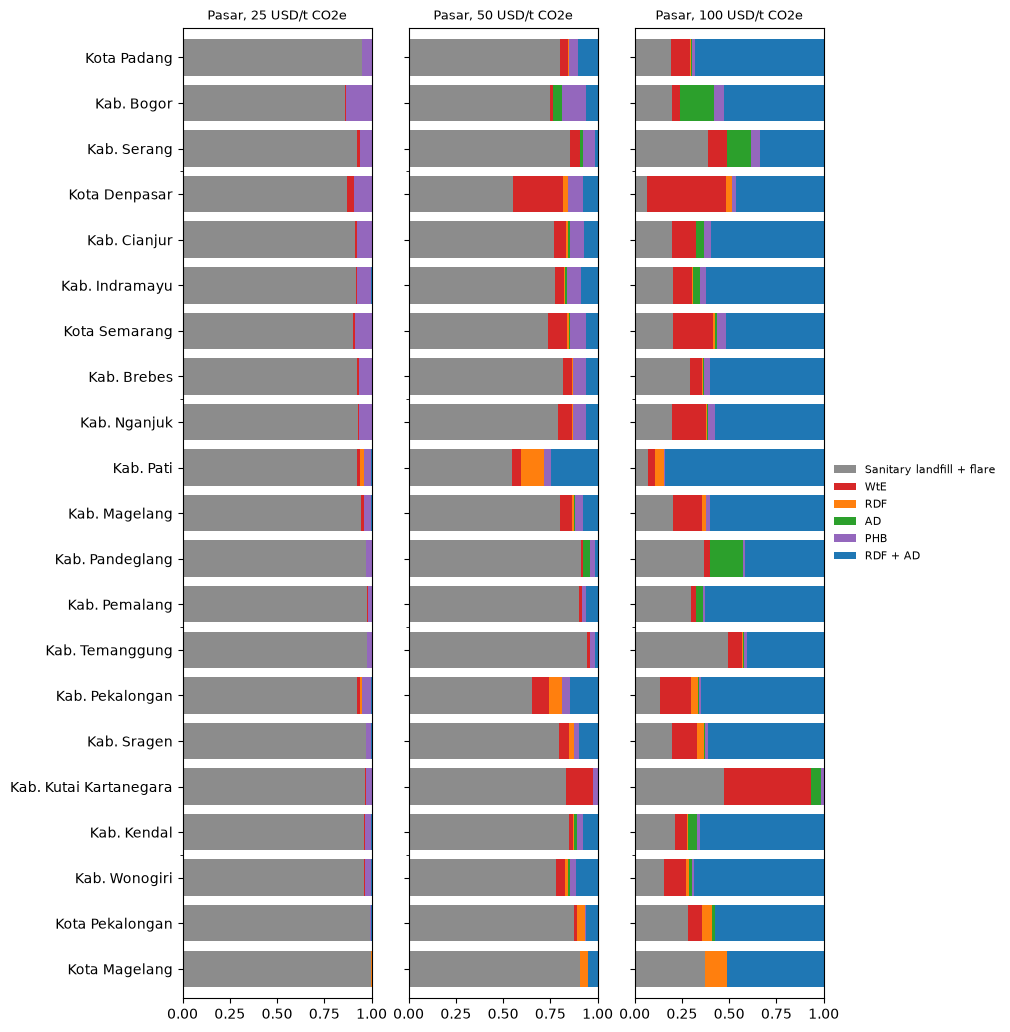

,city,Q,best_at_0,best_at_25,best_at_50,best_at_100
0,Kota Padang,656.0,SL,SL,SL,S5
1,Kab. Bogor,2891.1,SL,SL,SL,S5
2,Kab. Serang,1187.0,SL,SL,SL,S5
3,Kota Denpasar,918.5,SL,SL,SL,S5
4,Kab. Cianjur,1113.7,SL,SL,SL,S5
5,Kab. Indramayu,1151.9,SL,SL,SL,S5
6,Kota Semarang,1190.0,SL,SL,SL,S5
7,Kab. Brebes,1033.0,SL,SL,SL,S5
8,Kab. Nganjuk,744.0,SL,SL,SL,S5
9,Kab. Pati,691.4,SL,SL,SL,S5


Reports: outputs/user_reports/rips21_report.xlsx and .html


In [3]:
raw21 = read_input("data/input_kota_2025_updated.csv")
A21 = analyse(M, raw21, N=1000, scenarios=("market", "perpres109", "AD_feed_optimistic", "food_separated_at_source"))
prob_figure(A21, LANG); plt.show()
display(A21["best"][A21["best"].scenario == "market"].drop(columns=["scenario"]).round(1))
write_excel(A21, "outputs/user_reports/rips21_report.xlsx", LANG); write_html(A21, "outputs/user_reports/rips21_report.html", LANG)
print("Reports: outputs/user_reports/rips21_report.xlsx and .html")

## Step 2. Your own cities / Kota Anda sendiri
1. Download the template (`templates/city_input_template.xlsx`, sheet *guide_panduan* explains every column).
2. Fill one row per city: tonnage and its year, composition in wet-mass % (leave blank what is not reported),
   grid region, and either coordinates or the road distance to a cement kiln.
3. Upload it below as CSV or XLSX. The validator stops on errors and lists every assumption it applies as a warning.

Outside Colab the shipped example (Kab. Pati and Kota Magelang) is used.

Errors: none
Warnings: none


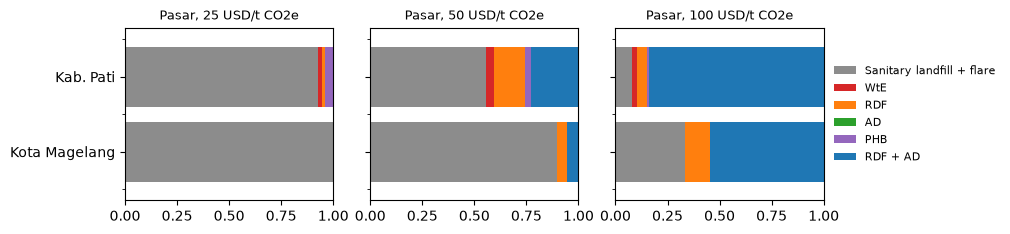

,city,scenario,Q,best_at_0,best_at_25,best_at_50,best_at_100
0,Kab. Pati,market,691.4,SL,SL,SL,S5
1,Kota Magelang,market,49.5,SL,SL,SL,S5
2,Kab. Pati,perpres109,691.4,SL,SL,SL,S5
3,Kota Magelang,perpres109,49.5,SL,SL,SL,S5
4,Kab. Pati,food_separated_at_source,691.4,SL,S3,S3,S5
5,Kota Magelang,food_separated_at_source,49.5,SL,SL,S3,S3
6,Kab. Pati,moisture_IPCC_default,691.4,SL,SL,S5,S5
7,Kota Magelang,moisture_IPCC_default,49.5,SL,SL,SL,S5


,Kota,Opsi,Lolos syarat,GRK (kg CO2e/t),GRK terhindar vs open dump,GRK terhindar vs landfill,Biaya bersih (USD/t),Biaya abatemen vs landfill (USD/t CO2e),CED fosil (MJ/t),Kebutuhan lahan (m2/t)
0,Kab. Pati,Sanitary landfill + flare,True,453.0,344.0,0.0,18.1,NaN,78.0,0.081
1,Kab. Pati,WtE,True,171.0,627.0,282.0,49.1,110.0,-5579.0,0.019
2,Kab. Pati,RDF,True,136.0,661.0,317.0,36.5,58.0,-5768.0,0.053
3,Kab. Pati,AD,True,341.0,457.0,112.0,34.8,148.0,-40.0,0.072
4,Kab. Pati,PHB,True,442.0,356.0,11.0,34.6,1468.0,-452.0,0.081
5,Kab. Pati,RDF + AD,True,23.0,775.0,430.0,41.0,53.0,-6070.0,0.042
6,Kota Magelang,Sanitary landfill + flare,True,585.0,447.0,0.0,40.0,NaN,78.0,0.081
7,Kota Magelang,WtE,False,142.0,889.0,442.0,120.3,181.0,-4772.0,0.019
8,Kota Magelang,RDF,True,272.0,759.0,312.0,70.2,97.0,-4604.0,0.056
9,Kota Magelang,AD,True,457.0,575.0,128.0,65.8,201.0,-80.0,0.070


In [4]:
if IN_COLAB:
    from google.colab import files
    files.download("templates/city_input_template.xlsx")
    print("Fill the template, then upload it / Isi template lalu unggah:")
    up = files.upload(); fname = next(iter(up))
else:
    fname = "templates/city_input_template.csv"
user = pd.read_excel(fname, sheet_name=0) if fname.endswith("xlsx") else pd.read_csv(fname)
errors, warnings = validate_template(user, M)
print("Errors:", errors or "none"); print("Warnings:", warnings or "none")
if not errors:
    raw_user, warn = from_template(user, M)
    AU = analyse(M, raw_user, N=1000, warnings=warn,
                 scenarios=("market", "perpres109", "food_separated_at_source", "moisture_IPCC_default"))
    prob_figure(AU, LANG); plt.show()
    display(AU["best"].round(1)); display(central_table(AU, LANG))
    p1 = write_excel(AU, "outputs/user_reports/my_cities_report.xlsx", LANG)
    p2 = write_html(AU, "outputs/user_reports/my_cities_report.html", LANG)
    if IN_COLAB: files.download(str(p1)); files.download(str(p2))

## Step 3. Interactive form for one city / Formulir interaktif satu kota
The form starts with Kab. Pati's numbers from the example template. Change them and press *Run* / *Jalankan*.

In [5]:
from mswpath.ui import city_form
example = pd.read_csv("templates/city_input_template.csv").iloc[0].to_dict()
from mswpath.core import km
# road distance to the nearest kiln from the example's coordinates (great-circle x road factor of the register)
example["kiln_road_km"] = round(min(km((example["lat"], example["lon"]), v) for v in M.KILN.values()) * M.REG.central["tort"], 1)
city_form(M, LANG, example=example);

## Step 4. Decision rules: when does each option win? / Aturan keputusan
The model is run over thousands of combinations of conditions a planner can observe or choose: carbon value,
tonnage, distance to a cement kiln, grid, WtE tariff, source separation of food, composition, moisture, landfill gas
collection and landfill cost (all other parameters sampled from the register). A shallow decision tree and PRIM boxes
summarise which conditions favour which option. Composition spans the 21 RIPS compositions; outside that range the
rules are extrapolations.

Share of draws in which each option is best:


best
SL    0.510
S3    0.299
S1    0.101
S5    0.069
S4    0.021
S2    0.001
Name: proportion, dtype: float64

Tree accuracy on held-out draws: 0.77 (majority-class baseline 0.51)


,rule,predicted,purity,share_of_draws
0,food_separated = no AND Q_tpd <= 1.01e+03 AND ...,SL,0.98,0.18
12,food_separated = yes AND carbon_value > 50.8 A...,S3,0.83,0.18
11,food_separated = yes AND 28.8 < carbon_value <...,S3,0.66,0.08
2,food_separated = no AND Q_tpd <= 1.01e+03 AND ...,SL,0.53,0.08
1,food_separated = no AND Q_tpd <= 1.01e+03 AND ...,SL,0.86,0.08
9,food_separated = yes AND 12.3 < carbon_value <...,SL,0.69,0.06
14,food_separated = yes AND carbon_value > 28.8 A...,S1,0.56,0.05
8,food_separated = yes AND carbon_value <= 12.3 ...,SL,0.91,0.04
13,food_separated = yes AND carbon_value > 28.8 A...,S3,0.85,0.04
6,food_separated = no AND Q_tpd > 1.01e+03 AND L...,SL,0.56,0.04


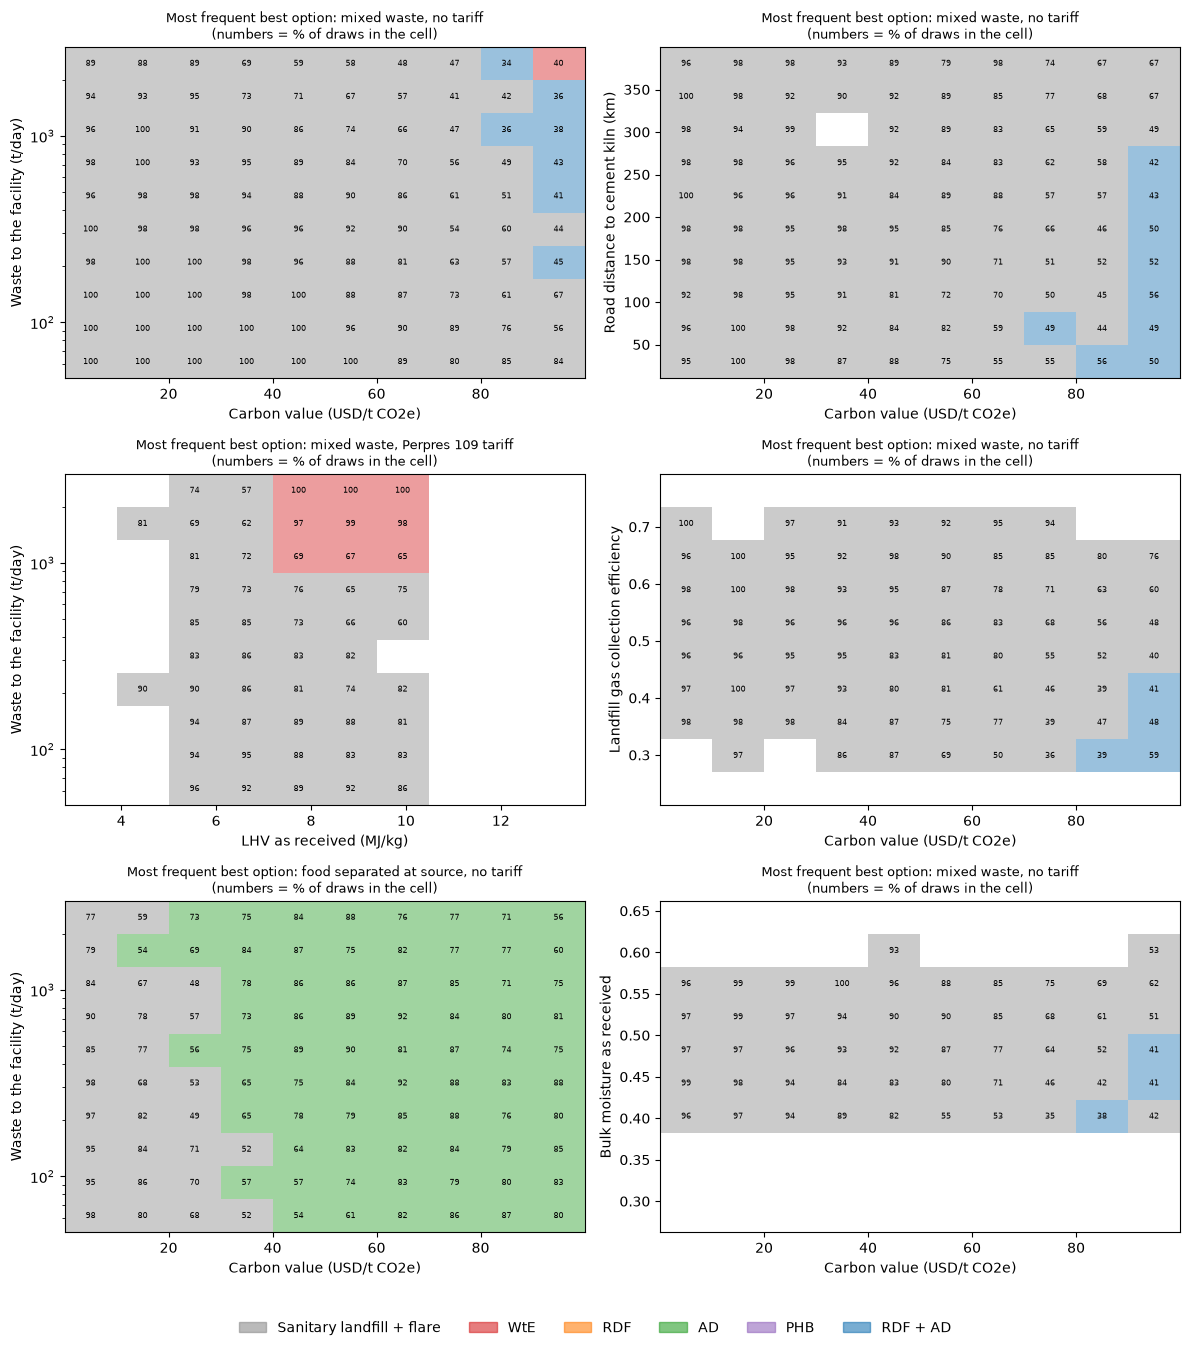

In [6]:
from mswpath.discovery import sample_conditions, cart_rules, prim_box, plot_condition_maps
M.load_cities(raw21)
X, best, _, meta = sample_conditions(M, N=20000, seed=7)
print("Share of draws in which each option is best:"); display(best.value_counts(normalize=True).round(3))
CT = cart_rules(X, best, max_depth=4)
print(f"Tree accuracy on held-out draws: {CT['acc_test']:.2f} (majority-class baseline {CT['baseline_acc']:.2f})")
leaves = CT["leaves"].sort_values("share_of_draws", ascending=False)
display(leaves[["rule", "predicted", "purity", "share_of_draws"]].round(2))
plot_condition_maps(X, best, close=False); plt.show()

In [7]:
# Where does a city sit? Change the values to describe your city and read the tree's prediction.
my_city = dict(carbon_value=50, Q_tpd=500, kiln_km=120, grid_ef=0.87, tariff=0, food_separated=0,
               food_share=0.45, plastic_share=0.18, paper_garden_share=0.20, moisture=0.50, LHV=7.0,
               gas_capture=0.5, landfill_cost=20)
for pc in (0, 25, 50, 100):
    q = pd.DataFrame([{**my_city, "carbon_value": pc}])[X.columns]
    print(f"carbon value {pc:>3} USD/t -> {NAMES[CT['tree'].predict(q)[0]]}")

carbon value   0 USD/t -> Sanitary landfill + flare
carbon value  25 USD/t -> Sanitary landfill + flare
carbon value  50 USD/t -> Sanitary landfill + flare
carbon value 100 USD/t -> Sanitary landfill + flare


## Step 5. Break-even targets and what to measure first / Target impas dan data yang perlu diukur dulu
**Break-even**: how good must one input be (all others central) for an option to match the sanitary landfill on
carbon-inclusive cost? These are targets a tender, pilot or offtake contract would have to reach.
'never' = the option stays dearer over the whole tested range; 'always' = it is cheaper over the whole range.

**Value of information (EVPPI)**: the most a city should pay, per tonne and per year, to resolve a group of uncertain
inputs before choosing. Groups with high values are the measurements to make first.

In [8]:
from mswpath.thresholds import threshold_table
from mswpath.voi import voi_groups
M.load_cities(raw21)
CITY = "kota_padang"      # change to any city_id in M.H.index
THR = threshold_table(M, locations=[CITY], carbon_values=(25, 50, 100))
display(THR.pivot_table(index=["option", "input", "better_if", "central_value"], columns="carbon_value",
                        values="break_even", aggfunc="first"))
i = list(M.H.index).index(CITY)
_, smp = M.run_mc("market", N=2000, keep=True)
P_, s_, R_ = smp[CITY]
for pc in (25, 50, 100):
    g, evpi = voi_groups(P_, s_, R_, M.FR, pc=pc)
    q = M.H.loc[CITY].Q2025 * 365
    print(f"\nCarbon value {pc} USD/t CO2e: EVPI {evpi:.2f} USD/t = {evpi * q:,.0f} USD/yr")
    display(g.assign(usd_per_year=g.evppi_net * q)[["group", "evppi_net", "usd_per_year"]].round(3))

carbon_value                                           25               50   \
option input      better_if central_value                                     
S1     K_wte      lower     1.200000e+08   48065475.202674  72601576.360637   
       o_wte      lower     2.700000e+01             never         7.604896   
       p_el       higher    7.000000e-02          0.151834         0.123921   
S2     cap        lower     5.000000e-01             never            never   
       o_rdf      lower     1.840000e+01          3.491637         8.885932   
       p_rdf      higher    1.150000e+00          4.317821         3.171608   
S3     cap        lower     5.000000e-01             never            never   
       o_ad       lower     1.400000e+01             never            never   
       pre_ofmsw  lower     5.000000e+00             never            never   
       y_pen_mech higher    6.000000e-01             never            never   
S5     cap        lower     5.000000e-01             never         0.282072   
       o_rdf      lower     1.840000e+01          1.541981        11.078627   
       p_rdf      higher    1.150000e+00          4.764453         2.719743   
       pre_ofmsw  lower     5.000000e+00             never            never   
       y_pen_mech higher    6.000000e-01             never            never   

carbon_value                                            100  
option input      better_if central_value                    
S1     K_wte      lower     1.200000e+08   121673778.676564  
       o_wte      lower     2.700000e+01          27.684899  
       p_el       higher    7.000000e-02           0.068096  
S2     cap        lower     5.000000e-01           0.534307  
       o_rdf      lower     1.840000e+01          19.674522  
       p_rdf      higher    1.150000e+00           0.879182  
S3     cap        lower     5.000000e-01           0.471057  
       o_ad       lower     1.400000e+01          10.881977  
       pre_ofmsw  lower     5.000000e+00           1.881977  
       y_pen_mech higher    6.000000e-01           0.723927  
S5     cap        lower     5.000000e-01           0.674904  
       o_rdf      lower     1.840000e+01           30.15192  
       p_rdf      higher    1.150000e+00             always  
       pre_ofmsw  lower     5.000000e+00             always  
       y_pen_mech higher    6.000000e-01             always


Carbon value 25 USD/t CO2e: EVPI 0.22 USD/t = 52,856 USD/yr


,group,evppi_net,usd_per_year
4,WtE performance and cost,0.0,0.0
0,"Waste characterisation (moisture, composition)",0.0,0.0
2,"RDF line and off-take (O&M, CAPEX, price, coal...",0.0,0.0
5,Landfill cost,0.0,0.0
6,"Finance (discount rate, lifetime, scale exponent)",0.0,0.0
7,Grid and electricity price,0.0,0.0
3,"AD on mixed waste (yield, penalty, capture, co...",0.0,0.0
1,"Landfill gas performance (collection, DOC, F, ...",0.0,0.0



Carbon value 50 USD/t CO2e: EVPI 1.26 USD/t = 301,148 USD/yr


,group,evppi_net,usd_per_year
0,"Waste characterisation (moisture, composition)",0.074,17729.789
1,"Landfill gas performance (collection, DOC, F, ...",0.022,5360.305
2,"RDF line and off-take (O&M, CAPEX, price, coal...",0.004,926.248
4,WtE performance and cost,0.000,52.806
5,Landfill cost,0.000,0.000
7,Grid and electricity price,0.000,0.000
6,"Finance (discount rate, lifetime, scale exponent)",0.000,0.000
3,"AD on mixed waste (yield, penalty, capture, co...",0.000,0.000



Carbon value 100 USD/t CO2e: EVPI 3.14 USD/t = 752,206 USD/yr


,group,evppi_net,usd_per_year
1,"Landfill gas performance (collection, DOC, F, ...",0.468,112079.803
0,"Waste characterisation (moisture, composition)",0.305,73004.897
4,WtE performance and cost,0.303,72558.614
2,"RDF line and off-take (O&M, CAPEX, price, coal...",0.008,1867.274
3,"AD on mixed waste (yield, penalty, capture, co...",0.001,262.226
5,Landfill cost,0.000,0.000
7,Grid and electricity price,0.000,0.000
6,"Finance (discount rate, lifetime, scale exponent)",0.000,0.000


## Step 6. Caveats and citation / Catatan dan sitasi
- Screening LCA/TEA with class-5 costs; per tonne of mixed MSW at the facility gate in 2025.
- Composition is a sampling-year proxy for 2025; it is not a measured 2025 composition.
- Moisture as received, dry heating values and RDF transfer coefficients are assumptions. With the drier IPCC default
  moisture, RDF + AD overtakes the landfill at 50 USD/t CO2e in 7 of 21 locations; with the high moisture bound or a
  22% lower RDF heating value, RDF + AD loses its lead at 100 USD/t CO2e in 17 of 21. Measured as-received moisture
  and RDF quality are therefore the first data to collect.
- The managed-waste share has different definitions across sources; results on managed tonnage are comparable only
  within one definition.
- CED and land-use factors are partly analyst assumptions (`data/lcia_factors.csv`).
- Results are reported at fixed carbon values (0, 2, 25, 50, 100 USD/t CO2e; 2 = UU 7/2021 carbon tax) because the
  carbon value is a policy choice. A small lead in probability means the decision depends on inputs that are still
  uncertain, not Monte Carlo noise (the standard error is reported); Step 5 shows which inputs.
- AD of food separated from mixed waste is penalised (methane yield 0.6 of source-separated food, extra pre-treatment);
  the scenario `AD_feed_optimistic` removes the penalty.
- The facilities do not exist: results are ex-ante screening, to be confirmed by feasibility studies and local data.
- Decision rules from Step 4 are approximations of the model (see accuracy).

Cite: Ridwan, M.F., Halog, A. (2026). *mswpath: provenance-aware screening of MSW recovery pathways for Indonesian
cities*, v3.2 (see `CITATION.cff`). Methodology: `docs/MSW_Methodology_v3_EN.pdf`.